In [1]:
import pandas as pd
import numpy as np
from FaceQuant import FaceQuantVec
import os
from tqdm import tqdm

## Load data

In [16]:
import os

csv_files = []

for root, dirs, files in os.walk('C2shortvideosDLCanalyzed/'):
    for f in files:
        if f.endswith('.csv') and not 'Resnet50' in f:
            csv_files.append(os.path.join(root, f))



In [17]:
all_results = []

for csv_file in tqdm(csv_files):
    df = pd.read_csv(csv_file, header=[1, 2])
    df.columns.names = ["scorer", "bodyparts"]
    n = len(df)

    if n > 200:
        fq = FaceQuantVec(df)
        quant_df = fq.compute()
    
        if "Airpuff" in csv_file:
            quant_df["stimuli"] = ["neutral"] * 200 + ["airpuf"] * (n - 200)
        elif "quinine" in csv_file:
            quant_df["stimuli"] = ["neutral"] * 200 + ["quinine"] * (n - 200)
        elif "Sucrose" in csv_file:
            quant_df["stimuli"] = ["neutral"] * 200 + ["sucrose"] * (n - 200)
    
        all_results.append(quant_df)

fq_df = pd.concat(all_results, ignore_index=True)


100%|██████████| 205/205 [00:03<00:00, 53.40it/s]


In [18]:
from scipy.stats import zscore

quant_cols = [
    "eye_opening",
    "ear_opening",
    "ear_position",
    "snout_position",
    "mouth_position",
    "face_inclination"
]

fq_df[quant_cols] = fq_df[quant_cols].apply(zscore)
import numpy as np

mean_df = fq_df.groupby("stimuli")[quant_cols].mean()
sem_df  = fq_df.groupby("stimuli")[quant_cols].sem()



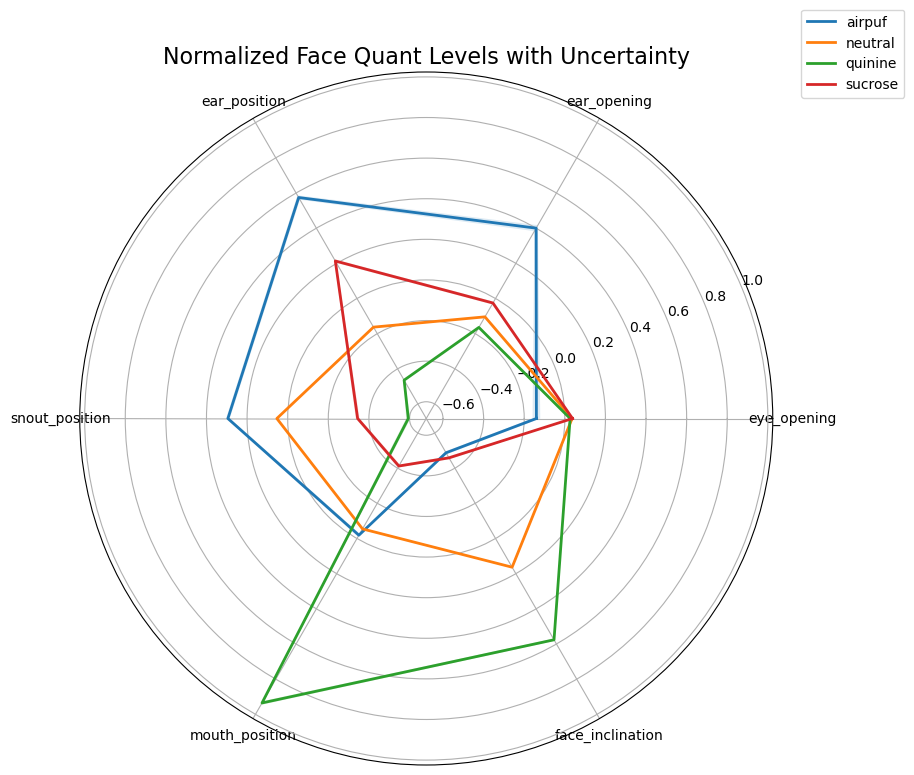

In [19]:
import matplotlib.pyplot as plt
import numpy as np

labels = quant_cols
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for stim in mean_df.index:
    values = mean_df.loc[stim].tolist()
    values += values[:1]

    sem = sem_df.loc[stim].tolist()
    sem += sem[:1]

    lower = np.array(values) - np.array(sem)
    upper = np.array(values) + np.array(sem)

    ax.plot(angles, values, linewidth=2, label=stim)
    ax.fill_between(angles, lower, upper, alpha=0.15)
    
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_title("Normalized Face Quant Levels with Uncertainty", size=16)
ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))

plt.show()
